# Đồ án nhận diện tin giả bằng mô hình học máy

## import các thư viện để sử dụng

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.metrics import Precision, Recall
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

import re
import joblib
from sklearn.model_selection import train_test_split
from underthesea import word_tokenize
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier

In [2]:
import warnings
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")
warnings.filterwarnings("ignore", category=Warning, module="tensorflow")

## Data description:
**Bộ dữ liệu được lấy từ nguồn:** Các trang báo của việt nam
***
Dataset trong file **data_train.csv** và **data_test.csv** có 4 đặc trưng là:
- `title` : Tựa đề của bài báo.
- `text`  : Nội dung bài báo.
- `author`: Tên tác giả.
- `source_domain`: Domain lấy tin.
- `label` : Tính đáng tin cậy.
***
Đặc trưng `label` có vai trò là target của mô hình dự đoán. Đặc trưng này mang 2 giá trị biểu diễn độ đáng tin cậy của bài báo:
* 1: tin giả (không đáng tin)
* 0: tin thật (đáng tin)
***

In [6]:
Data = pd.read_csv('data_train.csv', encoding = 'utf-8')
features = Data.columns.to_list()[:-1]
print(Data.shape)
print(features)

(1264, 5)
['title', 'text', 'author', 'source_domain']


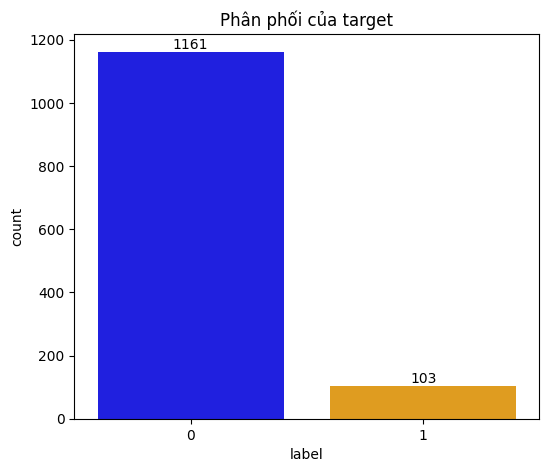

In [9]:
def plot_target(data, title):
    target_counts = data.value_counts('label').reset_index()  # Reset chỉ mục để có dataframe
    target_counts.columns = ['label', 'count']  # Đặt tên cột
    
    plt.figure(figsize=(6,5))
    
    # Vẽ biểu đồ với hue là cột 'label' để không nhận cảnh báo
    ax = sns.barplot(x='label', y='count', hue='label', data=target_counts, 
                     palette={0: 'blue', 1: 'orange'}, legend=False)
    
    ax.set_title(title)
    
    # Hiển thị giá trị của từng cột
    for i in ax.containers:
        ax.bar_label(i)
    
    plt.show()

# Ví dụ sử dụng
plot_target(Data, 'Phân phối của target')


## Text preprocessing

* Xem qua một vài instace để có một cái nhìn cơ bản về dataset

In [13]:
Data.head(10)

,title,text,author,source_domain,label
0,"Cấm biển, di dân khỏi vùng nguy hiểm từ Quảng ...",Các tỉnh ven biển phía Bắc cấp tập di dân tạm ...,Nhóm phóng viên,vnexpress.net,0
1,"Tàu cao tốc đi Phú Quốc, Côn Đảo, Lý Sơn dừng ...","Tàu, phà từ đất liền đi các đảo Phú Quốc, Côn ...",Nhóm phóng viên,vnexpress.net,0
2,"Đêm nay siêu bão Yagi vào vịnh Bắc Bộ, gây mưa...","Sáng nay, Yagi duy trì cấp siêu bão với sức gi...",Gia Chính,vnexpress.net,0
3,Đề xuất người nổi tiếng chỉ được quảng cáo sản...,"Người có tầm ảnh hưởng, người nổi tiếng đăng t...",Sơn Hà,vnexpress.net,0
4,Di dời hơn 13.000 hộ dân trước bão,"Người dân ở chung cư cũ, căn hộ xuống cấp, nhà...",Lê Tân,vnexpress.net,0
5,Đóng cửa 4 sân bay để tránh bão Yagi,"Bốn sân bay Vân Đồn, Cát Bi, Nội Bài, Thọ Xuân...",Đoàn Loan,vnexpress.net,0
6,Bộ Chính trị phân công người điều hành Tỉnh ủy...,"Ông Nguyễn Khắc Toàn, Phó bí thư thường trực T...",Bùi Toàn,vnexpress.net,0
7,Phó thủ tướng: Chống bão với tinh thần nghiêm ...,Chỉ còn 24h để ứng phó với siêu bão Yagi cấp 1...,Việt An,vnexpress.net,0
8,Lũ cát cuốn trôi người đi đường ở Phan Thiết,"Bình ThuậnLũ cát từ đồi cao bất ngờ ập xuống, ...",Việt Quốc,vnexpress.net,0
9,'Có cơ sở quá tải vẫn cố giữ trẻ em để hút tài...,Nhiều cơ sở trợ giúp xã hội ngoài công lập quá...,Hoàng Phương,vnexpress.net,0


In [17]:
Data.sample(10)

,title,text,author,source_domain,label
643,"Viễn thông đã bỏ độc quyền rất xuất sắc, khi n...","Sáng 29/8, Hội nghị đại biểu Quốc hội chuyên t...",Hoài Thu,dantri.com.vn,0
595,"Hàng nghìn tỷ đồng và sổ đỏ, hơn 500 cây vàng ...",Con số này được Chính phủ đề cập trong báo cáo...,Hoài Thu,dantri.com.vn,0
705,"Tổng Bí thư, Chủ tịch nước Tô Lâm chủ trì họp ...","Tổng Bí thư, Chủ tịch nước Tô Lâm cùng các đại...",NaN,dantri.com.vn,0
870,"Tổng Bí thư, Chủ tịch nước Tô Lâm chủ trì cuộc...","Ngày 21/8, tại Trụ sở Trung ương Đảng, Tổng Bí...",NaN,vietnamnet.vn,0
1186,"Còn hơn 3 tháng mới đến Tết, nhiều công nhân n...",Vợ chồng chị Nhàn quê ở Bình Phước đang bắt đầ...,Gia Minh,viettan.org,1
198,Ông Trần Hồng Thái làm Chủ tịch UBND Lâm Đồng,Nguyên thứ trưởng Bộ Khoa học và Công nghệ Trầ...,Trường Hà - Khánh Hương,vnexpress.net,0
634,Chủ tịch Bắc Giang cùng các cấp phó có vi phạm...,Việc xem xét kết quả kiểm tra khi có dấu hiệu ...,Hoài Thu,dantri.com.vn,0
734,"Tổng Bí thư, Chủ tịch nước Tô Lâm gặp gỡ đại d...","Tổng Bí thư, Chủ tịch nước Tô Lâm và các đại b...",NaN,dantri.com.vn,0
402,Hiện trường 8 ôtô đâm liên hoàn trên cầu Phú Mỹ,"TP HCMĐầu ôtô 4-7 chỗ và xe tải bị vỡ nát, móp...",Đình Văn - Thanh Tùng,vnexpress.net,0
47,"Bão Yagi tăng cấp, khả năng ảnh hưởng toàn miề...","Chiều nay, bão tăng lên cấp 10, dự báo đạt cấp...",Gia Chính,vnexpress.net,0


### Xem thông tin

In [18]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1264 entries, 0 to 1263
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          1264 non-null   object
 1   text           1264 non-null   object
 2   author         1216 non-null   object
 3   source_domain  1264 non-null   object
 4   label          1264 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 49.5+ KB


### Xem mô tả

In [19]:
Data.describe().round(1)

,label
count,1264.0
mean,0.1
std,0.3
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,1.0


### Xem số dòng và số cột của dữ liệu

In [21]:
num_rows=Data.shape[0]
num_cols=Data.shape[1]
print(num_rows)
print(num_cols)

1264
5


### Ý nghĩa các dòng

#### Kiểm tra dữ liệu có bị lặp

In [23]:
duplicate = Data.index.duplicated().sum()
duplicate

0

### Mỗi cột hiện đang có kiểu dữ liệu gì? Có cột nào có kiểu dữ liệu chưa phù hợp để có thể xử lý tiếp không?

In [27]:
Data.dtypes

title            object
text             object
author           object
source_domain    object
label             int64
dtype: object

#### Cột có dtype là object nghĩa là sao?
- Trong Pandas, kiểu dữ liệu object thường ám chỉ chuỗi, nhưng thật ra kiểu dữ liệu object có thể chứa một đối tượng bất kỳ trong Python (vì thật ra ở bên dưới kiểu dữ liệu object chứa địa chỉ).
- Nếu một cột trong dataframe có dtype là object thì có thể các phần tử trong cột này sẽ có kiểu dữ liệu khác nhau
- Để biết được kiểu dữ liệu thật sự của các phần tử trong cột này thì ta phải truy xuất vào từng phần tử. Ta muốn xem thử trong nội bộ mỗi cột này có các kiểu dữ liệu nào

In [28]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [30]:
open_object_dtype(Data['title'])

{str}

In [ ]:
open_object_dtype(Data['text'])

In [ ]:
open_object_dtype(Data['author'])

In [ ]:
open_object_dtype(Data['source_domain'])

#### Các thông tin thống kê

##### Chiều dài trung bình mỗi record là bao nhiêu?

In [32]:
len_sum=0
for i in Data['text']:
    len_sum+=len(i)
len_avg=len_sum/Data['text'].count()
len_avg

2900.0545886075947

##### Record dài nhất là bao nhiêu?

In [34]:
max_len=0
for i in Data['text']:
    if len(i)>max_len:
        max_len=len(i)
max_len

33691

##### Record ngắn nhất là bao nhiêu?

In [36]:
min_len=len(Data['text'][0])
for i in Data['text']:
    if len(i)<min_len:
        min_len=len(i)
min_len

10

##### Tin tức được thu thập từ trang web nào nhiều nhất?

In [37]:
Data['source_domain'].value_counts()

source_domain
vnexpress.net    586
dantri.com.vn    171
vietnamnet.vn    140
baomoi.com       118
viettan.org      103
thanhnien.vn      80
nhandan.vn        45
tuoitre.vn        21
Name: count, dtype: int64

### Dữ liệu bị miss

In [25]:
print("Dữ liệu bị miss")
for col in Data.columns:
    print(f"{col:<20}  {np.sum(pd.isnull(Data[col]))}")

Dữ liệu bị miss
title                 0
text                  0
author                48
source_domain         0
label                 0


Ta nhận thấy một số điểm sau:
- Đặc trưng `author` có một số giá trị bị thiếu. Đối với xử lý ngôn ngữ tự nhiên, ta có thể mặc định đây là những ký tự trống (''). 
   >Tuy nhiên, xét trên ngữ cảnh của bài toán phân loại tin giả, mối tương quan giữa việc không biết rõ tác giả với tính xác thực của bài báo là đáng quan tâm. <br>
&rarr;Vậy nên, ta cần quan sát thêm về mối tương quan giữa những giá trị bị thiếu này (`author`) đối với đặc trưng `target`.
- Bộ dữ liệu chứa nhiều ký tự đặc biệt không có ích cho quá trình dự đoán như `./>-` cần phải được loại bỏ.
- Các chữ cái viết hoa và viết thường không khác biệt nhau về nghĩa.

#### Author bị miss và xử lý

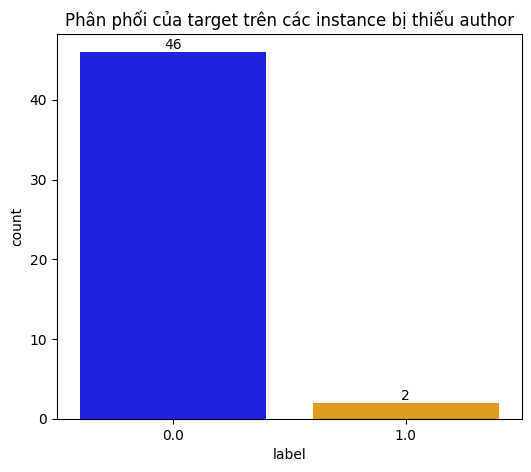

In [10]:
# đánh giá về phân bố của những instance có đặc trưng author bị thiếu.
observe_data = Data.where(Data['author'].isnull())
plot_target(observe_data, 'Phân phối của target trên các instance bị thiếu author')

&rarr; Vậy là luận điểm của em đã phần nào được chứng minh khi gần như toàn bộ những bài báo không rõ tác giả đều không đáng tin cậy. Dựa trên kinh nghiệm của bản thân, em sẽ impute những giá trị thiếu ở đặc trưng author là ***anonymousauthor*** để đảm bảo chúng được mô hình xem xét như một từ độc lập.

### Text cleaning

In [13]:
# Cài đặt một hàm để xử lý dữ liệu bị thiếu.
def handle_missing_values(data):
    newdata = pd.DataFrame()
    newdata['author'] = data['author'].fillna('anonymousauthor')
    cols = ['title', 'text']
    for i in cols:
        newdata[i] = data[i].fillna('')
    return newdata
        
# Cài đặt một hàm để đưa các chữ cái trong dữ liệu về chung dạng viết thường.
def lowcase_data(data):
    newdata = data.copy()
    for col in features:
        newdata[col] = data[col].str.lower()
    return newdata

# Cài đặt một hàm để loại bỏ những ký tự không phải chữ cái.
def remove_punctuations(text):
    x = re.sub(r'[^a-z ]', '',text)
    return ''.join(x)

- Xử lý missing values

In [14]:
cleaned_data = handle_missing_values(Data)
# gán lại Target cho tập train.
cleaned_data['label'] = Data['label']

In [15]:
print("Missing values counter on data")
for col in cleaned_data.columns:
    print(f"{col:<20}  {np.sum(pd.isnull(cleaned_data[col]))}")

Missing values counter on data
author                0
title                 0
text                  0
label                 0


- Hiển thị dữ liệu